# Tarımsal Veri Setleri — TensorFlow Ortamı ve Keşifsel Analiz

**Proje:** Akıllı Tarım Yönetim Sistemi (ATYS)  
**Amaç:** TensorFlow 2.x kurulumunu doğrulamak; sulama ve gübreleme optimizasyonu için açık kaynak veri setlerini incelemek.

---

## 1. Ortam ve TensorFlow (GPU / CPU) doğrulaması

In [1]:
import platform
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)
print('TensorFlow:', tf.__version__)
print('Built with CUDA:', tf.test.is_built_with_cuda())

physical_gpus = tf.config.list_physical_devices('GPU')
logical_gpus = tf.config.list_logical_devices('GPU')
print('Physical GPUs:', physical_gpus)
print('Logical GPUs:', logical_gpus)

# CPU matmul testi
with tf.device('/CPU:0'):
    a = tf.random.normal((512, 512))
    b = tf.random.normal((512, 512))
    c = tf.matmul(a, b)
print('CPU matmul shape:', tuple(c.shape))

if physical_gpus:
    with tf.device('/GPU:0'):
        d = tf.matmul(a, b)
    print('GPU matmul shape:', tuple(d.shape))
else:
    print('GPU: kullanılamıyor — eğitim CPU üzerinde yapılacak.')
    print('Not: Windows pip paketi genelde CUDA içermez; GPU için tensorflow[and-cuda] veya WSL2+CUDA gerekir.')

Python: 3.12.0
Platform: Windows-11-10.0.26200-SP0
NumPy: 2.1.3
Pandas: 3.0.3
TensorFlow: 2.19.1
Built with CUDA: False
Physical GPUs: []
Logical GPUs: []
CPU matmul shape: (512, 512)
GPU: kullanılamıyor — eğitim CPU üzerinde yapılacak.
Not: Windows pip paketi genelde CUDA içermez; GPU için tensorflow[and-cuda] veya WSL2+CUDA gerekir.


## 2. Araştırılan açık kaynak veri setleri

| Veri seti | Kaynak | Sulama / Gübreleme kullanımı | Durum |
|-----------|--------|------------------------------|-------|
| **Crop Recommendation** | Kaggle / IEEE DataPort / Harvestify | N,P,K + iklim → ürün seçimi; gübre ihtiyacı proxy | `Crop_recommendation.csv` (projede mevcut) |
| **Crop Recommendation (Harvestify)** | [GitHub Harvestify](https://github.com/Gladiator07/Harvestify) | Aynı yapı, işlenmiş kopya | İndirildi |
| **Fertilizer (Harvestify)** | Harvestify `Data-processed/fertilizer.csv` | N,P,K, pH, **soil_moisture** → gübre / sulama eşiği | İndirildi |
| **Fertilizer Prediction** | [GitHub AgroTechh](https://github.com/Lanchavi/AgroTechh) | Sıcaklık, nem, toprak nemi, NPK → gübre adı | İndirildi |
| Smart Irrigation (Kaggle) | kagglehub | Sulama kararı | Kaggle API anahtarı gerekli (403) |

**Sulama optimizasyonu** için en doğrudan sütunlar: `rainfall`, `humidity`, `soil_moisture`, `Moisture`.  
**Gübreleme optimizasyonu** için: `N`, `P`, `K`, `Fertilizer Name`, toprak tipi.

In [2]:
DATA_DIR = Path('../data').resolve()
print('Veri dizini:', DATA_DIR)
print('CSV dosyaları:')
for p in sorted(DATA_DIR.glob('*.csv')):
    print(f'  - {p.name} ({p.stat().st_size / 1024:.1f} KB)')

Veri dizini: C:\Users\mert\akilli-tarim-sistemi\backend\data
CSV dosyaları:
  - Crop_recommendation.csv (146.5 KB)
  - crop_recommendation_harvestify.csv (144.4 KB)
  - fertilizer_harvestify.csv (0.6 KB)
  - Fertilizer_prediction.csv (3.7 KB)
  - Sleep_health_and_lifestyle_dataset.csv (23.6 KB)


## 3. Yardımcı fonksiyon — temel istatistiksel özet

In [3]:
def analyze_dataset(df: pd.DataFrame, name: str) -> None:
    """shape, describe, null check ve benzersiz hedef sınıfları yazdırır."""
    print('=' * 60)
    print(f'📊 {name}')
    print('=' * 60)
    print(f'Shape: {df.shape[0]} satır × {df.shape[1]} sütun')
    print(f'Sütunlar: {list(df.columns)}')
    print(f'Dtypes:\n{df.dtypes}')
    print('\n--- Eksik değerler (null check) ---')
    nulls = df.isnull().sum()
    print(nulls if nulls.any() else 'Eksik değer yok ✓')
    print(f'\nToplam eksik hücre: {df.isnull().sum().sum()}')
    print('\n--- describe() (sayısal) ---')
    display(df.describe(include='all').T)
    cat_cols = df.select_dtypes(include=['object', 'string']).columns
    for col in cat_cols:
        print(f'\n{col} benzersiz ({df[col].nunique()}):', df[col].unique()[:12], '...' if df[col].nunique() > 12 else '')
    print()

## 4. Crop Recommendation Dataset (Kaggle)

Kaynak: [Kaggle — Crop Recommendation](https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset)  
Kullanım: Ürün seçimi + toprak besin (N,P,K) ve iklim girdileri ile gübreleme planı için temel özellik seti.

In [4]:
df_crop = pd.read_csv(DATA_DIR / 'Crop_recommendation.csv')
analyze_dataset(df_crop, 'Crop Recommendation (ATYS)')

📊 Crop Recommendation (ATYS)
Shape: 2200 satır × 8 sütun
Sütunlar: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']
Dtypes:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object

--- Eksik değerler (null check) ---
Eksik değer yok ✓

Toplam eksik hücre: 0

--- describe() (sayısal) ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
N,2200.0,NaN,NaN,NaN,50.551818,36.917334,0.0,21.0,37.0,84.25,140.0
P,2200.0,NaN,NaN,NaN,53.362727,32.985883,5.0,28.0,51.0,68.0,145.0
K,2200.0,NaN,NaN,NaN,48.149091,50.647931,5.0,20.0,32.0,49.0,205.0
temperature,2200.0,NaN,NaN,NaN,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,NaN,NaN,NaN,71.481779,22.263812,14.25804,60.261953,80.473146,89.948771,99.981876
ph,2200.0,NaN,NaN,NaN,6.46948,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,NaN,NaN,NaN,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117
label,2200,22,rice,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN



label benzersiz (22): <StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango']
Length: 12, dtype: str ...



In [5]:
# Sulama / gübreleme ile ilişkili sütunlar
irrigation_cols = ['humidity', 'rainfall']
fert_cols = ['N', 'P', 'K', 'ph']
print('Sulama proxy — humidity & rainfall:')
display(df_crop[irrigation_cols].describe())
print('\nGübreleme — N, P, K, pH:')
display(df_crop[fert_cols].describe())
print(f'\nÜrün sınıfı sayısı: {df_crop["label"].nunique()}')
df_crop['label'].value_counts().head(10)

Sulama proxy — humidity & rainfall:


,humidity,rainfall
count,2200.000000,2200.000000
mean,71.481779,103.463655
std,22.263812,54.958389
min,14.258040,20.211267
25%,60.261953,64.551686
50%,80.473146,94.867624
75%,89.948771,124.267508
max,99.981876,298.560117



Gübreleme — N, P, K, pH:


,N,P,K,ph
count,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,6.469480
std,36.917334,32.985883,50.647931,0.773938
min,0.000000,5.000000,5.000000,3.504752
25%,21.000000,28.000000,20.000000,5.971693
50%,37.000000,51.000000,32.000000,6.425045
75%,84.250000,68.000000,49.000000,6.923643
max,140.000000,145.000000,205.000000,9.935091



Ürün sınıfı sayısı: 22


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
Name: count, dtype: int64

## 5. Fertilizer Dataset (Harvestify)

Kaynak: [Harvestify — fertilizer.csv](https://github.com/Gladiator07/Harvestify/blob/master/Data-processed/fertilizer.csv)  
Kullanım: **soil_moisture** ile sulama ihtiyacı; N,P,K ile gübre formülasyonu.

In [6]:
df_fert_h = pd.read_csv(DATA_DIR / 'fertilizer_harvestify.csv', index_col=0)
analyze_dataset(df_fert_h, 'Fertilizer (Harvestify)')

📊 Fertilizer (Harvestify)
Shape: 22 satır × 6 sütun
Sütunlar: ['Crop', 'N', 'P', 'K', 'pH', 'soil_moisture']
Dtypes:
Crop                 str
N                  int64
P                  int64
K                  int64
pH               float64
soil_moisture      int64
dtype: object

--- Eksik değerler (null check) ---
Eksik değer yok ✓

Toplam eksik hücre: 0

--- describe() (sayısal) ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Crop,22,22,rice,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N,22.0,NaN,NaN,NaN,50.454545,36.315715,20.0,20.0,30.0,80.0,120.0
P,22.0,NaN,NaN,NaN,45.681818,32.634172,10.0,20.0,40.0,60.0,125.0
K,22.0,NaN,NaN,NaN,48.181818,51.698426,10.0,20.0,30.0,50.0,200.0
pH,22.0,NaN,NaN,NaN,5.409091,0.590326,4.0,5.5,5.5,5.5,6.5
soil_moisture,22.0,NaN,NaN,NaN,46.363636,20.827055,15.0,30.0,45.0,60.0,90.0



Crop benzersiz (22): <StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango']
Length: 12, dtype: str ...



## 6. Fertilizer Prediction Dataset (AgroTechh)

Kaynak: [AgroTechh — Fertilizer Prediction.csv](https://github.com/Lanchavi/AgroTechh)  
Kullanım: Sıcaklık, nem, toprak nemi → doğrudan **gübre ürün adı** tahmini (sınıflandırma).

In [7]:
df_fert_p = pd.read_csv(DATA_DIR / 'Fertilizer_prediction.csv')
df_fert_p.columns = df_fert_p.columns.str.strip()  # 'Humidity ' boşluk düzeltme
analyze_dataset(df_fert_p, 'Fertilizer Prediction (AgroTechh)')

📊 Fertilizer Prediction (AgroTechh)
Shape: 99 satır × 9 sütun
Sütunlar: ['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type', 'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name']
Dtypes:
Temparature        int64
Humidity           int64
Moisture           int64
Soil Type            str
Crop Type            str
Nitrogen           int64
Potassium          int64
Phosphorous        int64
Fertilizer Name      str
dtype: object

--- Eksik değerler (null check) ---
Eksik değer yok ✓

Toplam eksik hücre: 0

--- describe() (sayısal) ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Temparature,99.0,NaN,NaN,NaN,30.282828,3.502304,25.0,28.0,30.0,33.0,38.0
Humidity,99.0,NaN,NaN,NaN,59.151515,5.840331,50.0,54.0,60.0,64.0,72.0
Moisture,99.0,NaN,NaN,NaN,43.181818,11.271568,25.0,34.0,41.0,50.5,65.0
Soil Type,99,5,Loamy,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop Type,99,11,Sugarcane,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nitrogen,99.0,NaN,NaN,NaN,18.909091,11.599693,4.0,10.0,13.0,24.0,42.0
Potassium,99.0,NaN,NaN,NaN,3.383838,5.814667,0.0,0.0,0.0,7.5,19.0
Phosphorous,99.0,NaN,NaN,NaN,18.606061,13.476978,0.0,9.0,19.0,30.0,42.0
Fertilizer Name,99,7,Urea,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Soil Type benzersiz (5): <StringArray>
['Sandy', 'Loamy', 'Black', 'Red', 'Clayey']
Length: 5, dtype: str 

Crop Type benzersiz (11): <StringArray>
[      'Maize',   'Sugarcane',      'Cotton',     'Tobacco',       'Paddy',
      'Barley',       'Wheat',     'Millets',   'Oil seeds',      'Pulses',
 'Ground Nuts']
Length: 11, dtype: str 

Fertilizer Name benzersiz (7): <StringArray>
['Urea', 'DAP', '14-35-14', '28-28', '17-17-17', '20-20', '10-26-26']
Length: 7, dtype: str 



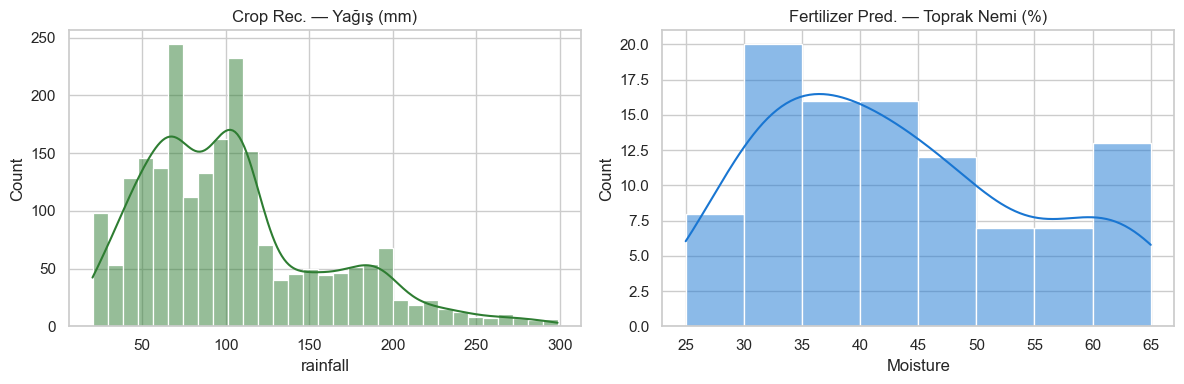

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_crop['rainfall'], kde=True, ax=axes[0], color='#2E7D32')
axes[0].set_title('Crop Rec. — Yağış (mm)')
sns.histplot(df_fert_p['Moisture'], kde=True, ax=axes[1], color='#1976D2')
axes[1].set_title('Fertilizer Pred. — Toprak Nemi (%)')
plt.tight_layout()
plt.show()

## 7. Karşılaştırmalı özet ve ATYS önerileri

| Veri seti | Satır | Eksik | Hedef | Sulama | Gübreleme |
|-----------|-------|-------|-------|--------|----------|
| Crop Recommendation | ~2200 | 0 | `label` (ürün) | rainfall, humidity | N, P, K |
| Fertilizer Harvestify | ~22 | 0 | Crop (küçük) | soil_moisture | N, P, K, pH |
| Fertilizer Prediction | ~100 | 0 | Fertilizer Name | Moisture, Humidity | N, P, K + formül |

**TensorFlow sonucu:** Kurulum başarılı; bu ortamda **CPU** kullanılıyor (CUDA derlemesi yok, GPU algılanmadı).

**Sonraki adımlar (ATYS):**
1. Crop Recommendation → mevcut `RandomForest` yerine/yanında `tf.keras` sınıflandırıcı
2. Fertilizer Prediction → gübre önerisi için ayrı TF modeli
3. `soil_moisture` / `rainfall` eşikleri → `CareRecommendation` sulama kuralları
4. MQTT telemetrisi ile canlı N, nem, pH beslemesi

In [9]:
# Mini TensorFlow modeli — Crop verisi üzerinde hızlı doğrulama (2 epoch)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X = df_crop[feature_cols].values.astype('float32')
le = LabelEncoder()
y = le.fit_transform(df_crop['label'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(le.classes_), activation='softmax'),
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1, verbose=1)
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest accuracy (TensorFlow CPU): {acc:.4f}')

Epoch 1/5


 1/50 ━━━━━━━━━━━━━━━━━━━━ 39s 808ms/step - accuracy: 0.0625 - loss: 3.1114

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0985 - loss: 3.0322   

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1528 - loss: 2.9345 - val_accuracy: 0.4375 - val_loss: 2.6092


Epoch 2/5


...

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7386 - loss: 1.1541 - val_accuracy: 0.7898 - val_loss: 0.8751


Epoch 5/5


 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8438 - loss: 0.9207

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7904 - loss: 0.8153 - val_accuracy: 0.8068 - val_loss: 0.6523



Test accuracy (TensorFlow CPU): 0.8205
